In [47]:
import os
from glob import glob
import numpy as np
import uproot
import matplotlib as mpl
import matplotlib.pyplot as plt
import awkward as ak  # Needed if using awkward arrays
from matplotlib.ticker import MultipleLocator, FuncFormatter
plt.style.use('fcc.mplstyle')


import config as cfg
import efficiency_finder

In [22]:
# data with no cuts and MC info for the quarks
base_folder = '/r01/lhcb/ejnw2/fcc/FCC_outputs_2025/outputs_28Jan25/no_selection_no_nlept_var/'

In [32]:
def histogram_settings():
    
    hist_settings = { allocation: {} for allocation in cfg.sample_allocations }
    total_color = { allocation: {} for allocation in cfg.sample_allocations }

    for allocation in cfg.sample_allocations:
        samples = cfg.sample_allocations[allocation]
            
        if allocation=='Bssignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[3]) #'cornflowerblue'
            hist_settings[allocation]['hatch'] = '////'
        elif allocation=='Bdsignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[-2]) #'mediumblue'#'royalblue'
            hist_settings[allocation]['hatch'] = r'\\\\'
        elif allocation=='combined_signal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] =plt.cm.Blues( np.linspace(0, 1, len(samples)+4)[3:-1] ) #['cornflowerblue','mediumblue']#['cornflowerblue', 'dodgerblue',]#['cadetblue','teal']#['cornflowerblue','mediumblue']
            total_color[allocation] = 'midnightblue'
            hist_settings[allocation]['hatch'] = '////'

        elif allocation=='hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(samples)+2)[1:-1] )
            total_color[allocation] = 'k'
        elif allocation=='light_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[3:-1] )
            total_color[allocation] = 'indianred'
        elif allocation=='heavy_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1:3] )
            total_color[allocation] = 'darkred'
        elif allocation=='bb_only':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['lw'] = 2
            #hist_settings[allocation]['alpha'] = 0.6
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )

        elif allocation=='tau_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[1])/5 )#'mediumvioletred'
            total_color[allocation] = 'indigo'
        elif allocation=='leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b( (4+np.linspace(0, 1, len(samples)+2)[1:-1]) /5 )# plt.cm.tab20b((4+ np.linspace(0, 1, len(samples)))/5 ) #plt.cm.PuRd_r( np.linspace(0, 1, len(samples)+2)[1:-1] ) 
            total_color[allocation] = 'indigo'#'purple'
        elif allocation=='light_leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[2:-1])/5 )
            total_color[allocation] = 'mediumvioletred'

    return hist_settings, total_color

In [33]:
def as_array(folder, varname, cut, nchunks,inputpath ):
    if nchunks is not None:
        files = glob(os.path.join(os.path.abspath(inputpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inputpath), folder, "*.root:events" )

    try: 
        # awkward array instead of numpy -> allows variable length elements
        #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
        arr = uproot.concatenate( path, expressions=varname, cut=cut)[varname]
    except:
        branches = get_list_of_branches(folder,inputpath)
        print( f"Branches found in files at path {folder}:" )
        for br in branches:
            print('  ', br)
        raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

    # Return awkward array as a flattened ndarray
    return ak.to_numpy(ak.ravel(arr))


In [34]:
bbpath = os.path.join(base_folder,'p8_ee_Zbb_ecm91/chunk_0.root')
sigpath = os.path.join(base_folder,'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu/chunk_0.root')

In [35]:
variables=[  'MCq2_p', 'MCq2_px', 'MCq2_py', 'MCq2_pz','MCq1_p', 'MCq1_px', 'MCq1_py', 'MCq1_pz', 'EVT_unitThrust_x', 'EVT_unitThrust_y', 'EVT_unitThrust_z' ]

sig_arr = uproot.concatenate( sigpath, expressions=variables)
bb_arr = uproot.concatenate( bbpath, expressions=variables)

In [39]:
sig_arr['MCq2_p']

MCq1_p_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_p'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_p']}
MCq1_px_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_px'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_px']}
MCq1_py_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_py'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_py']}
MCq1_pz_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': sig_arr['MCq1_pz'], 'p8_ee_Zbb_ecm91':bb_arr['MCq1_pz']}
MCq2_p_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_p'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_p']}
MCq2_px_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_px'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_px']}
MCq2_py_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_py'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_py']}
MCq2_pz_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['MCq2_pz'], 'p8_ee_Zbb_ecm91':bb_arr['MCq2_pz']}
EVT_Thrust_x_values =  {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_x'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_x']}
EVT_Thrust_y_values = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_y'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_y']}
EVT_Thrust_z_values  = {'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':sig_arr['EVT_unitThrust_z'], 'p8_ee_Zbb_ecm91':bb_arr['EVT_unitThrust_z']}

costheta1 = {sample: (MCq1_px_values[sample]*EVT_Thrust_x_values[sample]+MCq1_py_values[sample]*EVT_Thrust_y_values[sample]+MCq1_pz_values[sample]*EVT_Thrust_z_values[sample])/(MCq1_p_values[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}
theta1 = {sample: np.arccos(costheta1[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}

costheta2 = {sample: (MCq2_px_values[sample]*EVT_Thrust_x_values[sample]+MCq2_py_values[sample]*EVT_Thrust_y_values[sample]+MCq2_pz_values[sample]*EVT_Thrust_z_values[sample])/(MCq2_p_values[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}
theta2 = {sample: np.arccos(costheta2[sample]) for sample in ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']}

(array([46345.,  1843.,   702.,   414.,   182.,   155.,   374.,   735.,
         1839., 46477.]),
 array([0.        , 0.31415927, 0.62831855, 0.94247782, 1.2566371 ,
        1.57079637, 1.88495564, 2.1991148 , 2.51327419, 2.82743359,
        3.14159274]),
 <BarContainer object of 10 artists>)

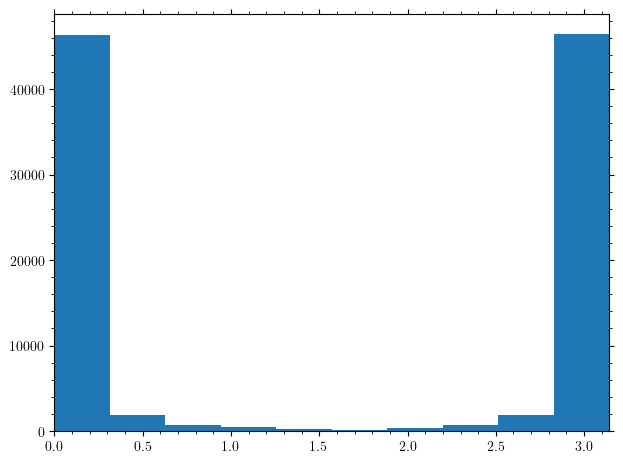

In [37]:
plt.hist(theta['p8_ee_Zbb_ecm91'])

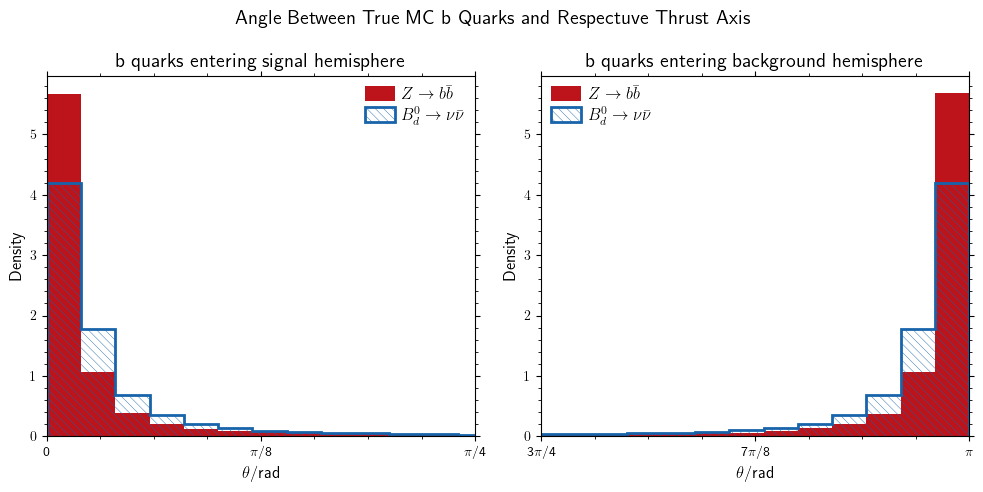

In [84]:
samples =  ['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91']

values1 = theta1
values2 = theta2

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
nbins=50

hist_settings,total_colours = histogram_settings()

for sample in samples:
    hist_x = values[sample]
    hist_l = cfg.titles[sample]
    if sample == 'p8_ee_Zbb_ecm91':
        hist_opts = hist_settings['bb_only']
        tot_colour= total_colours['bb_only']
    else:
        hist_opts = hist_settings['Bdsignal']
        tot_colour= total_colours['Bdsignal']

    hist_w = None

    hist_opts['stacked'] = False

    axs[0].hist( 
        x = hist_x,
        bins = nbins,
        density = True,
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )

    axs[1].hist( 
        x = hist_x,
        bins = nbins,
        density = True,
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )


axs[0].legend(reverse=True)
axs[0].set_xlabel(r'$\theta /$rad')
axs[0].set_xlim(0,np.pi/4)
#ax.set_yscale('log')
axs[0].set_ylabel('Density')

axs[1].legend(reverse=True)
axs[1].set_xlabel(r'$\theta /$rad')
axs[1].set_xlim(3*np.pi/4,np.pi)
#ax.set_yscale('log')
axs[1].set_ylabel('Density')

base_no = 8
def format_func(value, tick_number):
    # Convert the value to a fraction of π
    frac = value / np.pi
    if np.isclose(frac, 0):  # Handle 0
        return "0"
    elif np.isclose(frac, 1):  # Handle π
        return r"$\pi$"
    elif np.isclose(frac, -1):  # Handle -π
        return r"-$\pi$"
    else:
        numerator, denominator = int(np.round(frac * base_no)), base_no  # Adjust denominator as needed
        while numerator % 2 == 0 and denominator % 2 == 0:  # Simplify fraction
            numerator //= 2
            denominator //= 2
        if denominator == 1:  # If it's an integer multiple of π
            return f"{numerator}"+r"$\pi$"
        if numerator ==1:
            return r"$\pi$"+f"/{denominator}"
        else:
            return f"{numerator}"+r"$\pi$"+f"/{denominator}"



axs[0].xaxis.set_major_locator(MultipleLocator(base=np.pi / base_no))  # Set tick spacing
axs[0].xaxis.set_major_formatter(FuncFormatter(format_func))     # Format ticks as fractions of π


axs[1].xaxis.set_major_locator(MultipleLocator(base=np.pi / base_no))  # Set tick spacing
axs[1].xaxis.set_major_formatter(FuncFormatter(format_func))     # Format ticks as fractions of π

fig.suptitle('Angle Between True MC b Quarks and Respectuve Thrust Axis')
axs[0].set_title('b quarks entering signal hemisphere')
axs[1].set_title('b quarks entering background hemisphere')

plt.savefig('b_thrust_angle.pdf')
plt.show()


